# Generalized fold pipeline — pooled, whole-dataset train/test split(s)

**Author:** SF — **Branch:** `foldingstrategiesv2` — **Scope:** a *pipeline*, not an EDA
notebook: config at the top, split logic in the middle, a LogisticRegression-ready
`scikit-learn` `Pipeline` at the end. Nothing here is a one-off decision-trail write-up —
the goal is that this notebook keeps working (after editing `CONFIG`, not the logic below
it) once feature engineering lands a differently-shaped dataset.

## How this differs from `sf_logo_fold_strategy.ipynb`

That notebook holds one entire use case out to test generalization to a genuinely new
research question — the right question for "will this work on use case #7," but it means
every model only ever gets 5/6 of the use cases to train on, and the holdout is always a
full use case (large, specific).

**This notebook does not hold out a use case at all.** It pools all 6, and splits at the
*row* level — grouped by first-author (so the same author never straddles train and test)
and stratified on a `use_case_key + label` composite (so no split is accidentally skewed
toward one use case). This is the "generalized" fold strategy: it answers "how well does
this model do on more data from research questions it has already seen," which is a
different, and for a lot of everyday model-iteration decisions (feature selection,
hyperparameters, is this preprocessing choice even helping) the more relevant question —
`sf_logo_fold_strategy.ipynb` should still be the final generalization check before
shipping to a genuinely new use case, not a replacement for it.

## Why this is built as a config-driven pipeline, not a decision-trail notebook

Feature engineering for this project is being built in parallel, on a separate track. The
dataset this notebook eventually runs against will not be `data/processed/papers_combined.
parquet` as it exists today — it will have more (or renamed, or differently-typed)
engineered columns. Two things follow from that:

1. **Everything that could change with the dataset lives in one `CONFIG` dict** (column
   names, which columns are numeric/categorical features, split sizes) — the split logic,
   preprocessing, and model code below never hardcode a column name directly.
2. **Every fitted step (imputer, scaler, one-hot encoder, the model itself) is wrapped in a
   single `scikit-learn` `Pipeline`** (`scripts/fold_pipeline_utils.py`), so "fit only on
   the training rows" is enforced by `Pipeline.fit()` itself, not by remembering to call
   things in the right order by hand. That's the actual answer to "make this valid for a
   LogisticRegression, without leaking" — regardless of how the feature set grows.

**Tested today against `papers_combined.parquet`** (§0 flags the one stand-in feature it's
missing that the real dataset will already have) — see §6 for exactly what to change when
the real engineered dataset replaces it.


In [1]:
import sys
from pathlib import Path

SCRIPTS_DIR = Path("../../scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold

from fold_pipeline_utils import (
    bootstrap_auc_ci,
    build_pipeline,
    classification_metrics,
    prepare_dataset,
    ranking_metrics,
    validate_schema,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## CONFIG — the only section that should need to change for a new dataset

Every column name the rest of this notebook depends on is named here, once. When the
real engineered dataset replaces `papers_combined.parquet`: update `data_path`, extend
`numeric_feature_cols`/`categorical_feature_cols` with whatever new engineered columns
exist, and point `group_col`/`embedding_col` at their actual names if different. See §6
for the full checklist.


In [2]:
CONFIG = {
    "data_path": "../../data/processed/papers_combined.parquet",
    # target
    "target_col": "triage_label",
    "positive_label": "positive",
    "negative_labels": ["negative"],  # rows outside positive_label/negative_labels are dropped (e.g. this repo's `pass`)
    # columns used by the split/leakage logic, not as model features
    "use_case_col": "use_case_key",
    "group_col": "first_author",       # derived from group_source_col below if not already present
    "group_source_col": "authors",
    "title_col": "title",               # for the duplicate-row leakage check in §2
    # model features - extend these two lists as feature engineering lands new columns;
    # nothing else in this notebook needs to change
    "embedding_col": "embedding",       # expanded into emb_0..emb_{d-1} by prepare_dataset, dimensionality inferred at runtime
    "numeric_feature_cols": ["citation_velocity"],
    "categorical_feature_cols": [],
    # split sizes: StratifiedGroupKFold(n_splits=n_splits_outer) is built once and its
    # FIRST fold's test rows become the final holdout (~1/n_splits_outer of the pooled
    # data); the rest is train_pool, itself split n_splits_inner ways for validation.
    "n_splits_outer": 5,
    "n_splits_inner": 5,
    "random_state": 0,
}


## 0. Load data, and a stand-in for the still-in-progress feature engineering

**Temporary — delete this cell once the real engineered dataset lands.** `citation_velocity`
isn't in `papers_combined.parquet` yet (it's derived ad hoc in the EDA notebooks); the
feature-engineering track will ship it (and more) as a real column. Until then, this cell
recreates just enough of it here so `CONFIG["numeric_feature_cols"]` has something real to
point at and the pipeline below is actually exercised end-to-end, not just written.


In [3]:
df_raw = pd.read_parquet(CONFIG["data_path"])
print(f"Loaded {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns from {CONFIG['data_path']}")

# --- TEMPORARY stand-in, remove once the real engineered dataset provides this column ---
df_raw["exported_year"] = pd.to_datetime(df_raw["exported_at"]).dt.year
df_raw["paper_age"] = (df_raw["exported_year"] - df_raw["year"]).clip(lower=0)
df_raw["citation_velocity"] = df_raw["citation_count"] / (df_raw["paper_age"].astype("float") + 1)
# --- end temporary stand-in ---


Loaded 2,873 rows, 50 columns from ../../data/processed/papers_combined.parquet


## 1. Schema check + row-wise prep — safe on the WHOLE dataset, before any split

`validate_schema` fails loudly (naming exactly which `CONFIG` entries don't match) rather
than letting a mismatched dataset surface as a confusing error several cells later.

`prepare_dataset` only does **parameter-free, per-row** work: binarize the target, expand
the embedding column into scalar `emb_*` columns (inferring dimensionality from the data,
not hardcoded), and derive the author-grouping key if the dataset doesn't already provide
one. None of this estimates anything from the data's distribution, so none of it needs to
wait for a split — it's the same "row-wise deterministic vs. fitted-statistic" distinction
`citation_velocity`/`paper_age` already follow. Nothing past this cell is safe to run
before the split in §3.


In [4]:
validate_schema(df_raw, CONFIG)
df = prepare_dataset(df_raw, CONFIG)
print(f"{len(df):,} labelled rows (positive/negative only) after prepare_dataset")
print(f"Embedding expanded into {len(CONFIG['_embedding_feature_cols'])} columns "
      f"({CONFIG['_embedding_feature_cols'][0]}..{CONFIG['_embedding_feature_cols'][-1]})")
FEATURE_COLS = CONFIG["_embedding_feature_cols"] + CONFIG["numeric_feature_cols"] + CONFIG["categorical_feature_cols"]


1,852 labelled rows (positive/negative only) after prepare_dataset
Embedding expanded into 384 columns (emb_0..emb_383)


## 2. Duplicate-row leakage check

Even without holding out a use case, the same real paper can appear more than once in this
dataset (`sf_eda_v2.ipynb` §6.2's cross-use-case duplicate-title finding) — if one copy
lands in `train_pool` and the other in `final_holdout` after §3's split, that specific row
pair isn't a genuine train/test separation. Checked here, against the actual split, not
just flagged in the abstract. (Assumes a `title_col` exists in `CONFIG` — if the real
dataset uses a different dedup key, e.g. a DOI, point `CONFIG["title_col"]` at that
instead; the normalization logic below would need to change from string-lowercasing to
whatever matches that key's format.)


In [5]:
title_norm = df[CONFIG["title_col"]].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
n_dup_titles = title_norm.duplicated(keep=False).sum()
print(f"{n_dup_titles} rows share a title with at least one other row in the pooled dataset "
      f"(out of {len(df):,}) - checked against the actual split in §3.4 below.")


8 rows share a title with at least one other row in the pooled dataset (out of 1,852) - checked against the actual split in §3.4 below.


## 3. Where the split needs to happen, and why

**Everything above this line is safe pre-split** — it's either parameter-free (§1) or a
read-only check (§2). **Nothing below this line may fit anything using rows that end up in
`final_holdout` or in an inner validation fold.** The outer split happens first (§3.1),
carving out `final_holdout` — a slice of rows this notebook will not look at again until
§5. Everything else (`train_pool`) then gets its own inner split (§3.3) purely for
validation. This mirrors `sf_logo_fold_strategy.ipynb`'s outer/inner structure exactly —
the only difference is what defines the outer split (a random, grouped, stratified slice
of rows here, vs. a whole use case there).

### 3.1 Outer split — carve out `final_holdout`

`StratifiedGroupKFold(n_splits=n_splits_outer)` grouped by `first_author`, stratified on a
`use_case_key + label` composite key (so no split skews toward one use case by chance).
Its first fold's test rows become `final_holdout`, touched only once, in §5. The other
`n_splits_outer - 1` folds' worth of rows become `train_pool`.


In [6]:
strat_key_outer = df[CONFIG["use_case_col"]].astype(str) + "__" + df["y"].astype(str)
outer_cv = StratifiedGroupKFold(
    n_splits=CONFIG["n_splits_outer"], shuffle=True, random_state=CONFIG["random_state"]
)
outer_splits = list(outer_cv.split(df, strat_key_outer, groups=df[CONFIG["group_col"]]))
train_pool_idx, final_holdout_idx = outer_splits[0]

train_pool = df.iloc[train_pool_idx].reset_index(drop=True)
final_holdout = df.iloc[final_holdout_idx].reset_index(drop=True)

print(f"train_pool: {len(train_pool):,} rows | final_holdout: {len(final_holdout):,} rows "
      f"({len(final_holdout) / len(df):.1%} of the pooled dataset)")
print("\nuse_case_key share, train_pool vs. final_holdout (should be close if stratification worked):")
display(pd.concat([
    train_pool[CONFIG["use_case_col"]].value_counts(normalize=True),
    final_holdout[CONFIG["use_case_col"]].value_counts(normalize=True),
], axis=1, keys=["train_pool", "final_holdout"]).round(3))


train_pool: 1,481 rows | final_holdout: 371 rows (20.0% of the pooled dataset)

use_case_key share, train_pool vs. final_holdout (should be close if stratification worked):


,train_pool,final_holdout
use_case_key,,
solar_leo,0.194,0.194
soil_microbiome,0.192,0.194
ner,0.169,0.167
carbon_capture,0.160,0.162
tech_forecasting,0.142,0.143
cement_binders,0.142,0.140


### 3.2 Leakage checks on the outer split

In [7]:
overlap_authors = set(train_pool[CONFIG["group_col"]]) & set(final_holdout[CONFIG["group_col"]])
print(f"Authors present in both train_pool and final_holdout: {len(overlap_authors)} "
      f"(expected 0 - StratifiedGroupKFold guarantees this by construction)")

train_titles = set(title_norm.iloc[train_pool_idx])
holdout_titles = set(title_norm.iloc[final_holdout_idx])
n_title_leak = len(train_titles & holdout_titles)
print(f"Titles present in both train_pool and final_holdout: {n_title_leak} "
      f"(§2's {n_dup_titles} duplicate rows aren't grouped, so this CAN be non-zero even "
      f"though the author check above is always 0 - if it's non-zero, those specific "
      f"final_holdout rows' scores in §5 are optimistic)")


Authors present in both train_pool and final_holdout: 0 (expected 0 - StratifiedGroupKFold guarantees this by construction)
Titles present in both train_pool and final_holdout: 2 (§2's 8 duplicate rows aren't grouped, so this CAN be non-zero even though the author check above is always 0 - if it's non-zero, those specific final_holdout rows' scores in §5 are optimistic)


### 3.3 Inner split — validation folds within `train_pool`

Same scheme, one level down: `StratifiedGroupKFold(n_splits=n_splits_inner)` grouped by
`first_author`, stratified on the same composite key, computed *within* `train_pool` only
— `final_holdout` never informs this.


In [8]:
strat_key_inner = train_pool[CONFIG["use_case_col"]].astype(str) + "__" + train_pool["y"].astype(str)
inner_cv = StratifiedGroupKFold(
    n_splits=CONFIG["n_splits_inner"], shuffle=True, random_state=CONFIG["random_state"]
)
inner_splits = list(inner_cv.split(train_pool, strat_key_inner, groups=train_pool[CONFIG["group_col"]]))
print(f"{len(inner_splits)} inner validation folds built within train_pool ({len(train_pool):,} rows)")


5 inner validation folds built within train_pool (1,481 rows)


## 4. Fit the pipeline — train, validation, and (§5) holdout stages

Each inner fold gets a **fresh** `build_pipeline(CONFIG)` (imputer + scaler + encoder +
`LogisticRegression`, all one object). Calling `.fit()` on it fits every preprocessing
step on that fold's training rows alone — this is what makes the "transform for
LogisticRegression, without leaking" guarantee hold regardless of how `CONFIG["numeric_
feature_cols"]`/`categorical_feature_cols"]` grow.


In [9]:
val_rows = []
for tr_idx, te_idx in inner_splits:
    fold_pipeline = build_pipeline(CONFIG)
    fold_train, fold_test = train_pool.iloc[tr_idx], train_pool.iloc[te_idx]
    fold_pipeline.fit(fold_train[FEATURE_COLS], fold_train["y"])

    pos_col = list(fold_pipeline.classes_).index(1)
    proba = fold_pipeline.predict_proba(fold_test[FEATURE_COLS])[:, pos_col]
    pred = fold_pipeline.predict(fold_test[FEATURE_COLS])
    val_rows.append(classification_metrics(fold_test["y"].to_numpy(), proba, pred))

val_df = pd.DataFrame(val_rows)
print(f"Validation (inner CV, {len(inner_splits)} folds) - mean \u00b1 std")
display(val_df.agg(["mean", "std"]).round(3))


Validation (inner CV, 5 folds) - mean ± std


,auc,ap,recall,f2
mean,0.746,0.769,0.723,0.726
std,0.035,0.035,0.041,0.040


In [10]:
final_pipeline = build_pipeline(CONFIG)
final_pipeline.fit(train_pool[FEATURE_COLS], train_pool["y"])
pos_col = list(final_pipeline.classes_).index(1)

train_proba = final_pipeline.predict_proba(train_pool[FEATURE_COLS])[:, pos_col]
train_pred = final_pipeline.predict(train_pool[FEATURE_COLS])
train_metrics = classification_metrics(train_pool["y"].to_numpy(), train_proba, train_pred)
print("Train (in-sample, on train_pool itself)")
display(pd.Series(train_metrics).round(3))


Train (in-sample, on train_pool itself)


auc       0.930
ap        0.947
recall    0.859
f2        0.863
dtype: float64

## 5. Holdout — the one score this notebook only computes once

`final_pipeline` was fit on `train_pool` only. This is the first and only time
`final_holdout` is used.


In [11]:
holdout_proba = final_pipeline.predict_proba(final_holdout[FEATURE_COLS])[:, pos_col]
holdout_pred = final_pipeline.predict(final_holdout[FEATURE_COLS])
holdout_metrics = classification_metrics(final_holdout["y"].to_numpy(), holdout_proba, holdout_pred)
holdout_metrics.update(ranking_metrics(final_holdout["y"].to_numpy(), holdout_proba))
ci_lo, ci_hi = bootstrap_auc_ci(final_holdout["y"].to_numpy(), holdout_proba)
holdout_metrics["auc_ci_low"], holdout_metrics["auc_ci_high"] = ci_lo, ci_hi

print("Holdout (final_holdout, touched for the first time just now)")
display(pd.Series(holdout_metrics).round(3))

stage_table = pd.DataFrame({
    "train": {k: train_metrics[k] for k in ["auc", "ap", "recall", "f2"]},
    "validation_mean": {k: val_df[k].mean() for k in ["auc", "ap", "recall", "f2"]},
    "validation_std": {k: val_df[k].std() for k in ["auc", "ap", "recall", "f2"]},
    "holdout": {k: holdout_metrics[k] for k in ["auc", "ap", "recall", "f2"]},
}).T.round(3)
print("\nTrain -> validation -> holdout, side by side")
stage_table


Holdout (final_holdout, touched for the first time just now)


auc                0.753
ap                 0.794
recall             0.714
f2                 0.718
recall_at_10pct    0.150
recall_at_20pct    0.286
wss_at_95          0.074
auc_ci_low         0.705
auc_ci_high        0.798
dtype: float64


Train -> validation -> holdout, side by side


,auc,ap,recall,f2
train,0.930,0.947,0.859,0.863
validation_mean,0.746,0.769,0.723,0.726
validation_std,0.035,0.035,0.041,0.040
holdout,0.753,0.794,0.714,0.718


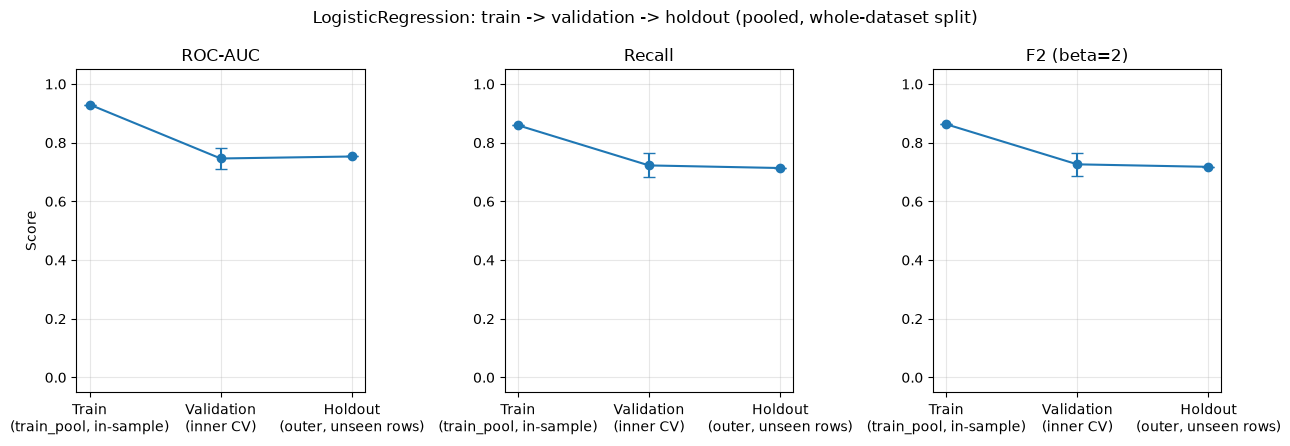

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True)
metrics_map = {"ROC-AUC": "auc", "Recall": "recall", "F2 (beta=2)": "f2"}
stage_labels = ["Train\n(train_pool, in-sample)", "Validation\n(inner CV)", "Holdout\n(outer, unseen rows)"]

for ax, (label, col) in zip(axes, metrics_map.items()):
    means = [train_metrics[col], val_df[col].mean(), holdout_metrics[col]]
    stds = [0, val_df[col].std(), 0]
    ax.errorbar(range(3), means, yerr=stds, marker="o", capsize=4, color="tab:blue")
    ax.set_xticks(range(3))
    ax.set_xticklabels(stage_labels)
    ax.set_title(label)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel("Score")
fig.suptitle("LogisticRegression: train -> validation -> holdout (pooled, whole-dataset split)")
plt.tight_layout()
plt.show()


**Hard finding — validation predicts holdout almost exactly here, unlike the LOGO
notebook.** Validation AUC (0.746 ± 0.035, inner CV) and holdout AUC (0.753) are within
one fold's own standard deviation of each other; Recall (0.723 validation vs. 0.714
holdout) and F2 (0.726 vs. 0.718) show the same pattern. There is essentially **no
validation→holdout gap** in this pooled, whole-dataset design — which is exactly what
should happen when `final_holdout` is just another random slice of rows from the *same*
6 use cases the model trained on, not a genuinely new domain. Compare this directly to
`sf_logo_fold_pipeline.ipynb` §5, where the equivalent gap is large: this contrast is the
actual point of building both notebooks side by side. A model can look "fine" — validation
predicting holdout accurately — while still being nowhere near ready for use case #7;
this notebook alone cannot tell you that, only `sf_logo_fold_pipeline.ipynb` can.

**Hard finding — the overfitting gap (train 0.930 → validation 0.746, ΔAUC 0.184) is real,
even for a single regularized `LogisticRegression`.** At 385 features (384 embedding
dimensions + `citation_velocity`) against ~1,481 training rows, some in-sample overfitting
is expected despite `class_weight="balanced"`'s default L2 regularization. This is a
separate problem from generalization-to-a-new-use-case (§4 above already isolates it from
that) and would be the right thing to address with stronger regularization (lower `C`) or
dimensionality reduction on the embedding block, independent of anything about use cases.

**On the leakage checks (§2, §3.2):** 8 of 1,852 rows share a title with another row
pooled-wide; 2 of those ended up split across `train_pool`/`final_holdout` after the
split. At a 371-row holdout, 2 rows is very unlikely to be moving `holdout_auc` by more
than rounding error, but it's a real, non-zero number worth fixing at the source
(`combine_use_cases.ipynb`) rather than dismissing.


## 6. Checklist — what to change when the real engineered dataset lands

1. Point `CONFIG["data_path"]` at the new file.
2. **Delete §0's "TEMPORARY stand-in" cell entirely** — the real dataset should already
   carry `citation_velocity` (or whatever the feature-engineering track actually names it).
3. Add every new engineered column to `CONFIG["numeric_feature_cols"]` or
   `CONFIG["categorical_feature_cols"]` (numeric vs. one-hot-encoded categorical) — nothing
   else in this notebook needs to change; `build_preprocessor` reads these lists directly.
4. If the new dataset already ships its own author/paper-grouping key under a different
   name, point `CONFIG["group_col"]` at it directly — `prepare_dataset` only derives one
   from `group_source_col` when `group_col` isn't already present.
5. If the embedding column's name or dimensionality changes, only `CONFIG["embedding_col"]`
   needs updating — the dimensionality is inferred at runtime, not hardcoded.
6. Re-run from the top. `validate_schema` (§1) will fail loudly, naming exactly which
   `CONFIG` entries don't match, if anything's still misaligned.
7. **The one thing this checklist can't fix for you:** if the feature-engineering pipeline
   itself computes any *fitted* statistic (a percentile rank, a global mean/std, a learned
   encoding) using the *full* dataset before handing it to this notebook, no amount of
   correct split timing here can undo that leak — it happened upstream. Flag this
   explicitly to the feature-engineering track: any such statistic needs to be computed
   per-fold, inside a split, exactly like this notebook's own `StandardScaler`/`SimpleImputer`
   are — not once, globally, before the data ever reaches this notebook.
